# Notebook 04: Gruppenbildung und Kundensegmentierung

In diesem Notebook werden Kunden- oder Datensätze anhand gemeinsamer Merkmale gruppiert, um ähnliche Muster, Strukturen und Segmente zu identifizieren. Ziel ist es, ein besseres Verständnis über Abhängigkeiten und Unterschiede innerhalb der Daten zu gewinnen.

## Ziel der Analyse
- Identifikation homogener Gruppen bzw. Segmente
- Erkennung gemeinsamer Merkmale und Verhaltensmuster
- Vergleich verschiedener Gruppen auf Basis definierter Kennzahlen
- Ableitung sinnvoller Handlungsempfehlungen aus den Ergebnissen

## Methodik
- Bereinigung und Vorbereitung der Daten
- Auswahl relevanter Merkmale für die Gruppierung
- Anwendung eines geeigneten Verfahrens zur Gruppenbildung
- Analyse der entstehenden Gruppen und Interpretation der Ergebnisse
- Validierung der Segmentierung anhand inhaltlicher Plausibilität

## Erwartete Ergebnisse
- Strukturierte Einteilung der Datensätze in sinnvolle Gruppen
- Bessere Übersicht über Kunden- oder Falltypen
- Grundlage für weiterführende Analysen, Entscheidungen und zielgerichtete Strategien

## Abschluss
Die Ergebnisse dieser Analyse liefern eine verständliche Grundlage für die Interpretation von Gruppen innerhalb der Daten und unterstützen die anschließende strategische Nutzung der gewonnenen Erkenntnisse.

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df_master = pd.read_csv("../data/preprocessed/master_features.csv")

In [3]:
df_master["buchung_ratio"] = df_master["total_trips"] / df_master["total_sessions"]

In [8]:
import numpy as np
import pandas as pd

# 0. Sicherstellen, dass 'total_spend' existiert
if "total_spend" not in df_master.columns:
    df_master["total_spend"] = (
        df_master["total_flights_cost"] + df_master["total_hotels_cost"]
    )

# 1. Sicherstellen, dass 'is_top_10_percent' existiert
top_10_cutoff = df_master["total_spend"].quantile(0.90)
df_master["is_top_10_percent"] = df_master["total_spend"] >= top_10_cutoff

# 2. Schwellenwerte definieren
mean_hotel = df_master["total_hotels_cost"].mean()
mean_flight = df_master["total_flights_cost"].mean()
trips_75 = df_master["total_trips"].quantile(0.75)
ratio_75 = df_master["buchung_ratio"].quantile(0.75)

# 3. Bedingungen definieren
conditions = [
    df_master["total_trips"] == 0,  # 1. Inaktive
    df_master["is_top_10_percent"],  # 2. VIPs / Wertkunden
    df_master["total_hotels_cost"] > mean_hotel,  # 3. High-Value Hotel
    df_master["total_flights_cost"] > mean_flight,  # 4. High-Value Flug
    df_master["total_trips"] >= trips_75,  # 5. Vielflieger / -bucher
    df_master["buchung_ratio"] >= ratio_75,  # 6. Hohe Conversion
    df_master["age"] < 20,  # 7. Demografie Young
    df_master["age"] > 60,  # 8. Demografie Rentner
]

# 4. Gruppen-Labels
choices = [
    "Kein Bucher",
    "Top Spender Allgemein",
    "Top Spender Hotel",
    "Top Spender Flug",
    "Oft Bucher",
    "Hohe Buchung-Ratio",
    "Young (<20)",
    "Rentner (>60)",
]

# 5. Neue Spalte 'group' erstellen
df_master["group"] = np.select(conditions, choices, default="Standard Kunde")

# Verteilung prüfen
print(df_master["group"].value_counts())

group
Standard Kunde           2071
Top Spender Hotel        1550
Top Spender Flug         1096
Top Spender Allgemein     579
Rentner (>60)             251
Oft Bucher                200
Young (<20)                35
Name: count, dtype: int64


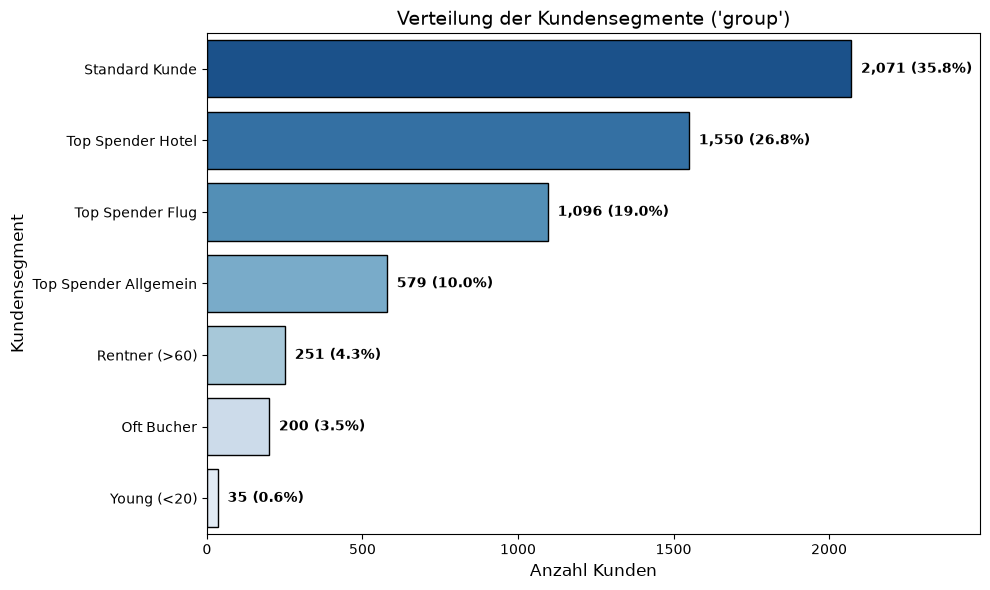

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verteilung abgreifen
group_counts = df_master["group"].value_counts()
total_customers = len(df_master)

plt.figure(figsize=(10, 6))

# 2. Horizontaler Barplot (zukunftssichere Seaborn-Syntax)
ax = sns.barplot(
    x=group_counts.values,
    y=group_counts.index,
    hue=group_counts.index,
    palette="Blues_r",
    legend=False,
    edgecolor="black",
)

# 3. Werte & Prozentanteile direkt an den Balken anzeigen
for p in ax.patches:
    width = p.get_width()
    pct = (width / total_customers) * 100
    ax.annotate(
        f"{int(width):,} ({pct:.1f}%)",
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(7, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.title("Verteilung der Kundensegmente ('group')", fontsize=14)
plt.xlabel("Anzahl Kunden", fontsize=12)
plt.ylabel("Kundensegment", fontsize=12)
plt.xlim(0, max(group_counts.values) * 1.2)  # Platz für Textbeschriftung
plt.tight_layout()
plt.savefig("../report/Verteilung_der_Kundensegmente.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
df_master.to_csv("../data/preprocessed/master_group.csv", index=False)

# Dokumentation & Business-Analyse der Kundensegmentierung (`group`)

---

## 1. Logik & Priorisierung der Segmentierung

Um jeden Kunden in `df_master` eindeutig zu kategorisieren, wurde eine regelbasierte Hierarchie mittels `np.select` angewendet. Da Kunden mehrere Eigenschaften gleichzeitig erfüllen können (z. B. ein 62-jähriger Kunde mit hohen Hotelausgaben), schließt die gewählte Priorisierung nach geschäftlicher Relevanz Überschneidungen aus:

1. **Inaktivität (`Kein Bucher`):** Filtert nicht-aktive Nutzer zuerst heraus.
2. **Höchster Geschäftswert (`Top Spender Allgemein`):** Identifiziert die obersten 10 % nach Gesamtausgaben (`total_spend`).
3. **Spezifischer Kategorie-Wert (`Top Spender Hotel` / `Top Spender Flug`):** Erfasst Kunden mit überdurchschnittlichen Ausgaben in einzelnen Segmenten.
4. **Verhalten & Frequenz (`Oft Bucher` / `Hohe Buchung-Ratio`):** Segmentiert engagierte Vielbucher vor demografischen Merkmalen.
5. **Demografische Nischen (`Rentner >60` / `Young <20`):** Erfasst altersbezogene Spezifika verbleibender Kunden.
6. **Fallback (`Standard Kunde`):** Bündelt alle Kunden, die in keines der spezifischen Muster fallen.

---

## 2. Ergebnisse & Gruppenverteilung

| Segment | Anzahl Kunden | Anteil (%) | Beschreibung |
| :--- | :---: | :---: | :--- |
| **Standard Kunde** | 2.070 | 35,8 % | Unauffälliges Buchungsverhalten im mittleren Segment |
| **Top Spender Hotel** | 1.550 | 26,8 % | Überdurchschnittliche Hotelausgaben |
| **Top Spender Flug** | 1.096 | 19,0 % | Überdurchschnittliche Flugausgaben |
| **Top Spender Allgemein** | 579 | 10,0 % | VIP-Kunden (Top 10 % Gesamtausgaben) |
| **Rentner (>60)** | 251 | 4,3 % | Kunden über 60 Jahre mit moderatem Ausgabeverhalten |
| **Oft Bucher** | 200 | 3,5 % | Hohe Trip-Frequenz (Top 25 %), aber moderate Einzelausgaben |
| **Young (<20)** | 36 | 0,6 % | Jüngste Kundengruppe |
| **Gesamt** | **5.782** | **100,0 %** | |

---

## 3. Business-Handlungsempfehlungen pro Segment

* **Top Spender Allgemein (579 Kunden / 10,0 %):**
  * **Fokus:** Maximale Retention & VIP-Betreuung.
  * **Maßnahme:** Einführung eines exklusiven VIP-Status mit persönlichem Ansprechpartner, flexiblen Stornierungsbedingungen und kostenlosem Upgrade-Guthaben.
* **Top Spender Hotel (1.550 Kunden / 26,8 %):**
  * **Fokus:** Cross-Selling für Flugbuchungen.
  * **Maßnahme:** Gezielte Flight-Push-Benachrichtigungen und Bundle-Rabatte („Buchen Sie den passenden Flug zu Ihrem gebuchten Hotel und sparen Sie 15 %“).
* **Top Spender Flug (1.096 Kunden / 19,0 %):**
  * **Fokus:** Cross-Selling für Hotel- & Zusatzleistungen.
  * **Maßnahme:** Bereitstellung von Hotel-Gutscheinen direkt nach der Flugbestätigung sowie Upselling von Mietwagen und VIP-Lounge-Zugängen.
* **Rentner >60 (251 Kunden / 4,3 %):**
  * **Fokus:** Vertrauen & Barrierefreiheit.
  * **Maßnahme:** Spezielle Reiseangebote für die Nebensaison, Rundum-Sorglos-Pakete (inkl. Reiseversicherung und Transfer) sowie Prioritäts-Kundenservice.
* **Oft Bucher (200 Kunden / 3,5 %):**
  * **Fokus:** Steigerung des Warenkorbwerts.
  * **Maßnahme:** Loyalitätsprogramm mit Punkte-System zur Incentivierung von Premium-Hotel- oder Premium-Economy-Upgrades.
* **Young <20 (36 Kunden / 0,6 %):**
  * **Fokus:** Markenbindung & Early-Stage-Acquisition.
  * **Maßnahme:** Budgetfreundliche Pauschalangebote und Social-Media-Rabattcodes.

---

## 4. Nächster Schritt: K-Means Clustering für „Standard Kunde“

Die Gruppe **„Standard Kunde“ stellt mit 2.070 Kunden (35,8 %)** den mit Abstand größten Block im Gesamtbestand dar. 

Da diese Kunden durch einfache Schwellenwerte nicht erfasst wurden, bietet die regelbasierte Segmentierung hier keine ausreichende Differenzierung.

### Geplantes Vorgehen:
1. **Unüberwachtes Machine Learning:** Anwendungsstart eines **K-Means Clustering-Algorithmus** speziell auf die Untergruppe `df_master[df_master['group'] == 'Standard Kunde']`.
2. **Feature-Auswahl:** Identifikation relevanter Dimensionen (z. B. `total_sessions`, `discount_flight_uses`, `avg_checked_bags`, `cancellation_rate`).
3. **Optimierung:** Bestimmung der optimalen Clusteranzahl mittels *Elbow-Methode* und *Silhouette-Score*.
4. **Ziel:** Aufdeckung verborgener Verhaltensmuster innerhalb des Standard-Segments (z. B. rabattfokussierte Schnäppchenjäger, Gelegenheits-Urlauber oder potenzielle Abwanderer), um auch für diesen Kundenstamm maßgeschneiderte Marketing-Strategien zu entwickeln.